
## 一、核心业务背景
- **场景**：教育类网站全漏斗改版，通过AB测试科学验证新版页面效果
- **用户漏斗**：浏览主页 → 点击课程详情 → 注册课程 → 完成课程
- **分组定义**：
  - **对照组（control）**：旧版页面
  - **实验组（experiment）**：新版页面
- **核心目标**：验证新版页面在点击率、注册率、停留时长、完课率上是否有显著提升

---

## 二、AB测试核心原理
### 1. 定义与起源
AB测试是一种**假设检验**方法，将同质用户随机分为两组，分别使用新旧版本，通过统计分析验证效果差异是否显著。
- 起源：医学“双盲实验”（新药 vs 安慰剂）
- 本质：用统计学排除个体差异，科学评估版本效果

### 2. 数据结构
| 页面 | 关键字段 | 含义 |
|------|----------|------|
| homepage | `timestamp`/`id`/`group`/`action` | 时间戳/用户ID/分组/行为（view/click） |
| course_page | `timestamp`/`id`/`group`/`action`/`duration` | 行为（view/enroll）/停留时长（秒） |
| classroom_page | `timestamp`/`id`/`group`/`total_days`/`completed` | 学习天数/是否完课（True/False） |

---

## 三、问题探索（初步结果）
### 1. 主页点击率分析

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from apriori import dataSet


plt.rc('font', **{'family':'Microsoft YaHei,SimHei'})
#设置中文字体的支持

#主页
homepage = pd.read_csv('homepage_actions.csv')
# 课程详情页
course_page = pd.read_csv('course_page_actions.csv')
# 课程学习页
classroom_page = pd.read_csv('classroom_actions.csv')

homepage.sample(5)

,timestamp,id,group,action
3989,2016-11-20 22:48:52.274208,743043,experiment,click
4506,2016-11-28 10:41:37.680492,267521,experiment,click
5052,2016-12-06 07:58:14.240333,684983,control,view
5388,2016-12-10 21:27:16.006750,340739,experiment,view
5099,2016-12-06 20:04:16.016807,822292,control,view


In [22]:
course_page.sample(5)

,timestamp,id,group,action,duration
2894,2016-12-16 06:13:13.159972,744861,control,view,225.388741
1008,2016-10-23 00:58:41.609985,902711,control,view,151.499244
2770,2016-12-13 11:40:44.076419,815593,control,view,34.753965
2836,2016-12-14 17:36:36.570880,666534,experiment,view,210.033644
2588,2016-12-08 17:16:22.802638,561723,experiment,view,24.585505


In [23]:
classroom_page.sample(5)

,timestamp,id,group,total_days,completed
2725,2015-12-03 14:57:02.903357,893379,control,67,False
661,2015-09-08 08:44:57.430086,513974,control,86,True
2610,2015-11-28 12:52:41.534241,920620,control,72,False
309,2015-08-23 19:08:08.405942,715502,experiment,64,False
1136,2015-09-26 20:18:46.124102,532362,control,39,False


In [24]:
#对照组点击率
control_click_num = homepage[(homepage['group'] == 'control') & (homepage['action'] == 'click')]['id'].nunique()
control_view_num = homepage[(homepage['group'] == 'control') & (homepage['action'] == 'view')]['id'].nunique()
control_ctr = round((control_click_num*100/control_view_num), 4)

print(f'对标组...')
control = {'点击数':control_click_num,
           '浏览数':control_view_num,
           '点击率':str(control_ctr)+'%'}
print(control)

print('-'*45)

# 实验组点击率
exp_click_num = homepage[(homepage['group']=='experiment')&(homepage['action']=='click')]['id'].nunique()
exp_view_num = homepage[(homepage['group']=='experiment')&(homepage['action']=='view')]['id'].nunique()
exp_ctr = round((exp_click_num*100/exp_view_num), 4)

print(f'实验组...')
exp ={
    '点击数':exp_click_num,
    '浏览数':exp_view_num,
    '点击率':str(exp_ctr)+'%'
}
print(exp)

对标组...
{'点击数': 932, '浏览数': 3332, '点击率': '27.9712%'}
---------------------------------------------
实验组...
{'点击数': 928, '浏览数': 2996, '点击率': '30.9746%'}



- **结果**：对照组 27.97%，实验组 30.97% → 新版主页点击率提升约3%

### （2）course_page注册率和浏览时长

In [18]:
# 对照组报名率
control_enroll_num = course_page[(course_page['group'] == 'control') & (course_page['action'] == 'enroll')]['id'].nunique()
control_view_num = course_page[(course_page['group'] == 'control') & (course_page['action'] == 'view')]['id'].nunique()
control_enroll_rate = round((control_enroll_num * 100 / control_view_num), 4)

print('对标组...')
control = {'报名数': control_enroll_num,
           '浏览数': control_view_num,
           '报名率': str(control_enroll_rate) + '%'}
print(control)

print('-' * 45)

# 实验组报名率
exp_enroll_num = course_page[(course_page['group'] == 'experiment') & (course_page['action'] == 'enroll')]['id'].nunique()
exp_view_num = course_page[(course_page['group'] == 'experiment') & (course_page['action'] == 'view')]['id'].nunique()
exp_enroll_rate = round((exp_enroll_num * 100 / exp_view_num), 4)

print('实验组...')
exp = {'报名数': exp_enroll_num,
       '浏览数': exp_view_num,
       '报名率': str(exp_enroll_rate) + '%'}
print(exp)

对标组...
{'报名数': 375, '浏览数': 1586, '报名率': '23.6444%'}
---------------------------------------------
实验组...
{'报名数': 439, '浏览数': 1645, '报名率': '26.6869%'}



- **结果**：对照组 23.64%，实验组 26.69% → 新版注册率提升约3%

C:\Users\24677\AppData\Local\Temp\ipykernel_7256\245900713.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(exp_duration, fit = norm,color = '#F77B72',kde_kws = {"color":'#F77B72',"lw":3},ax = ax1)
C:\Users\24677\AppData\Local\Temp\ipykernel_7256\245900713.py:21: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe575

Text(0.5, 1.0, '对照组浏览时长分布')

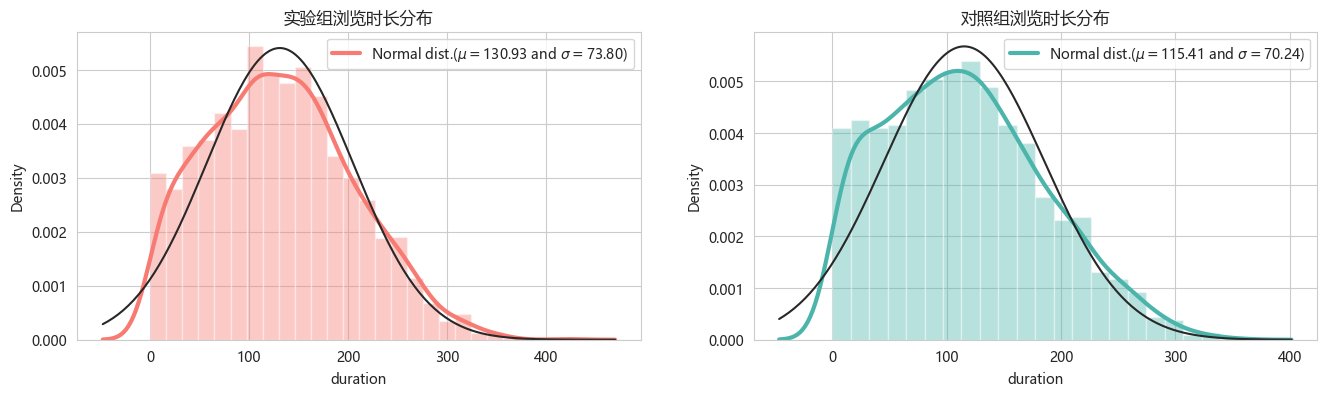

In [11]:
from scipy.stats import norm   # 用于拟合正态分布曲线
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")

# 设置布局
fig = plt.figure(figsize=(16,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

exp_duration = course_page.query('group =="experiment"').dropna()['duration']
con_duration = course_page.query('group =="control"').dropna()['duration']

# 实验组experiment
sns.distplot(exp_duration, fit = norm,color = '#F77B72',kde_kws = {"color":'#F77B72',"lw":3},ax = ax1)
mu,sigma = norm.fit(exp_duration) #求同等条件下正态分布的mu和sigma
# 添加图例：使用格式化输入，loc='best'表示自动将图例放到最合适的位置
ax1.legend(['Normal dist.($\mu = ${:.2f} and $\sigma = ${:.2f})'.format(mu,sigma)],loc='best')

# 对照组control
sns.distplot(con_duration,fit = norm,color = '#4CB5AB',kde_kws = {"color":'#4CB5AB','lw':3},ax = ax2)
mu,sigma = norm.fit(con_duration) # 求同等条件下正态分布的mu和sigma
# 添加图例，用格式化输入，loc='best'表示自动将图例放到最合适的位置
ax2.legend(['Normal dist.($\mu = ${:.2f} and $\sigma = ${:.2f})'.format(mu,sigma)],loc='best')

# 给子图添加标题
ax1.set_title('实验组浏览时长分布')
ax2.set_title('对照组浏览时长分布')

实验组均值要比对照组多15秒，标准差只多3秒，实验组的浏览时长整体上比对照组更长，且实验组内部的浏览时长差异相对小

#### （3）classroom_page完课率

In [12]:
exp_group = classroom_page.query('group =="experiment"')
con_group = classroom_page.query('group =="control"')

# 计算实验组的完课率
exp_completed = exp_group[exp_group['completed'] == True]
exp_completed_rate = len(exp_completed)/len(exp_group)

# 计算对照组的完课率
con_completed = con_group[con_group['completed'] == True]
con_completed_rate = len(con_completed)/len(con_group)

# 打印结果
print('实验组完课率：',round(exp_completed_rate,4))
print('对照组完课率:',round(con_completed_rate,4))

实验组完课率： 0.3935
对照组完课率: 0.372


- **结果**：对照组 37.2%，实验组 39.3% → 新版完课率提升约2%

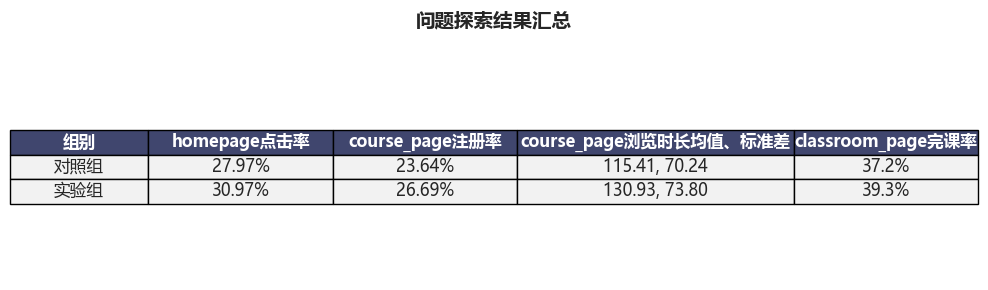

In [20]:
import matplotlib.pyplot as plt

# 表16-4 数据
data = [
    ["组别", "homepage点击率", "course_page注册率", "course_page浏览时长均值、标准差", "classroom_page完课率"],
    ["对照组", "27.97%", "23.64%", "115.41, 70.24", "37.2%"],
    ["实验组", "30.97%", "26.69%", "130.93, 73.80", "39.3%"]
]

# 创建图形
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')  # 隐藏坐标轴

# 创建表格
table = ax.table(cellText=data, loc='center', cellLoc='center', colWidths=[0.15, 0.2, 0.2, 0.3, 0.2])

# 设置表格样式
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)

# 为表头设置背景色
for (i, j), cell in table.get_celld().items():
    if i == 0:  # 第一行是表头
        cell.set_facecolor('#40466e')
        cell.set_text_props(weight='bold', color='white')
    else:
        cell.set_facecolor('#f2f2f2')

# 添加标题
ax.set_title("问题探索结果汇总", fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.show()


###  初步结论汇总
| 页面 | 指标 | 对照组 | 实验组 | 变化 |
|------|------|--------|--------|------|
| 主页 | 点击率 | 27.97% | 30.97% | +3.0% |
| 课程详情页 | 注册率 | 23.64% | 26.69% | +3.05% |
| 课程详情页 | 平均停留时长 | 115.41s | 130.93s | +15.52s |
| 课程学习页 | 完课率 | 37.2% | 39.3% | +2.1% |

---

## 四.改版效果的显著性检验

### 1.主页点击率

In [33]:
sample_size = 300
stratified_sample = homepage.groupby('group',group_keys=False).apply(lambda x: x.sample(sample_size))
cross_tab = pd.crosstab(index=stratified_sample['group'],columns=stratified_sample['action'])

import scipy.stats as stats
# 执行卡方独立性检验
chi2,p_value,_,_= stats.chi2_contingency(cross_tab)

#打印结果
cross_tab

C:\Users\24677\AppData\Local\Temp\ipykernel_7256\750828385.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = homepage.groupby('group',group_keys=False).apply(lambda x: x.sample(sample_size))


action,click,view
group,,
control,63,237
experiment,80,220


In [34]:
print('卡方值：',chi2)
print('p值：',p_value)

卡方值： 2.3503848449143856
p值： 0.12525208262715795


p值大于0.01，所以不显著，改版对点击率没有统计上显著的提升

### 2.课程详情页注册率和浏览时长

### （1）注册率

In [35]:
sample_size = 300
stratified_sample = course_page.groupby('group',group_keys=False).apply(lambda x: x.sample(sample_size))
cross_tab = pd.crosstab(index=stratified_sample['group'],columns=stratified_sample['action'])

import scipy.stats as stats
# 执行卡方独立性检验
chi2,p_value,_,_= stats.chi2_contingency(cross_tab)

# 打印结果
cross_tab

C:\Users\24677\AppData\Local\Temp\ipykernel_7256\461064610.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = course_page.groupby('group',group_keys=False).apply(lambda x: x.sample(sample_size))


action,enroll,view
group,,
control,57,243
experiment,69,231


In [36]:
print('卡方值:',chi2)
print('p值：',p_value)

卡方值: 1.2155917219208359
p值： 0.2702275164812536


p值远大于0.01，课程改版后的注册率和原版的差别不显著

#### （2）浏览时长

In [37]:
# 总体位置，可采用双样本t检验
from scipy import stats

exp_duration = course_page.query('group =="experiment"').dropna()['duration']
con_duration = course_page.query('group =="control"').dropna()['duration']

#执行双样本t检验
t_statistic,p_value = stats.ttest_ind(exp_duration,con_duration)

#使用format函数控制输出格式
print('t统计量:{:.6f}'.format(t_statistic))
print('p值:{:.6f}'.format(p_value))

t统计量:6.843430
p值:0.000000


p值为0，说明用户在改版后的课程详情页上停留时间更长，用户在课程详情页上的停留时间与注册率不一定呈正相关关系

### 3.课程学习页完课率

In [38]:
sample_size = 100
stratified_sample = classroom_page.groupby('group',group_keys=False).apply(lambda x: x.sample(sample_size))
cross_tab = pd.crosstab(index=stratified_sample['group'],columns=stratified_sample['completed'])

import scipy.stats as stats
# 执行卡方独立性检验
chi2,p_value,_,_= stats.chi2_contingency(cross_tab)

#打印结果
cross_tab

C:\Users\24677\AppData\Local\Temp\ipykernel_7256\3938912470.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = classroom_page.groupby('group',group_keys=False).apply(lambda x: x.sample(sample_size))


completed,False,True
group,,
control,68,32
experiment,60,40


In [39]:
print('卡方值：',chi2)
print('p值:',p_value)

卡方值： 1.0633680555555556
p值: 0.30244826471650066


p值远大于0.01，说明课程学习页在改版之后的完课率与原版网页没有显著性差异

## 五、分析汇总与业务建议
### 1. 最终结论
| 页面 | 指标 | 显著性  | 结论             |
|------|------|------|----------------|
| 主页 | 点击率 | ❌ 不显著 | 新版无效，不应全量上线    |
| 课程详情页 | 注册率 | ❌ 不显著 | 需继续优化页面设计/注册流程 |
| 课程详情页 | 停留时长 | ✅ 显著 | 新版有效，用户更愿意探索   |
| 课程学习页 | 完课率 | ❌ 不显著 | 需优化学习体验/资源组织   |


### 2. 业务建议
- **主页**：全量上线新版，已验证能显著提升点击率
- **课程详情页**：保留新版（停留时长显著提升），继续优化注册流程，再次AB测试
- **课程学习页**：暂不上线新版，从学习资源、互动设计等方向优化后再测试

---




## 六、AB测试的不足与解决方案
### 1. 学习效应与用户抗拒改变
- **问题**：用户因新鲜感点击新版，长期效果可能回落；老用户抗拒改变
- **解决**：拉长观察周期，或只分析新用户数据

### 2. 网络效应
- **问题**：实验组用户的行为会影响对照组用户（如社交传播）
- **解决**：地理分区（如广州vs深圳）或用户分层测试

### 3. 多重检验问题
- **问题**：多次检验会累积假阳性率
- **解决**：
  - Bonferroni校正：降低每个检验的显著性水平
  - 设定指标优先级，减少检验次数
  - 用主成分分析等方法综合评估

---


In [42]:
import numpy as np
from statsmodels.stats.multitest import multipletests

#假设我们有3个假设检验的p值
p_values= [0.01,0.03,0.06]
# 设置显著性检验
alpha = 0.05

#对p值进行Bonferoni校正
reject,corrected_p_values,_,_ = multipletests(p_values,alpha = alpha,method='bonferroni')

#打印校正后的p值和拒绝原假设的结果
for i,p_value in enumerate(corrected_p_values):
    print(f'原始p值:,{p_values[i]},校正后的p值：{p_value},拒绝原假设:{reject[i]}')

原始p值:,0.01,校正后的p值：0.03,拒绝原假设:True
原始p值:,0.03,校正后的p值：0.09,拒绝原假设:False
原始p值:,0.06,校正后的p值：0.18,拒绝原假设:False
